# Final Project
**Members:** Kris Nguyen, Anh Nguyen

# Thesis Statement:
Horror is the most "successful" genre in Hollywood, in other words, it produces the highest Return on Investment (ROI) regardless of critical reviews.

### 1. Data Preparation and Preprocessing
The dataset being used is an IMDb movies dataset about information of the films (names, genres, review scores, etc.) as well as financial data (budget and revenue). We categorizes our analysis against the foundational film genres (Action, Comedy, Drama, Fantasy, Horror, Mystery, Romance, Thriller, Western) [1].

To make sure our analysis only focused on the professional film industry, we set the threshold for the budget to be above $100,000.

The formula for our primary metric, ROI, is determined as follows: **Return on Investment (ROI)**, defined as `(Revenue - Budget) / Budget`.

Data set source: https://github.com/GettysburgDataScience/datasets/blob/main/movies/imdb_movies.csv

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [7]:
df = pd.read_csv('data/imdb_movies.csv')

In [8]:
df = df.dropna(subset=['budget_x', 'revenue', 'score', 'genre'])
df = df.query('budget_x >= 100000')

df['ROI'] = (df['revenue'] - df['budget_x']) / df['budget_x']

genres = ['Action', 'Comedy', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Thriller', 'Western']

for genre in genres:
    df[genre] = df['genre'].str.contains(genre)

### 2. Average ROI by Genre
To motivate our thesis, we first compared the average Return on Investment across the nine basic Hollywood genres as defined above. 

This establishes the foundation for our argument: Horror significantly outperforms other genres in terms of percentage yield. From the graph, we can see how horror offers the highest financial return in relation to their budget.

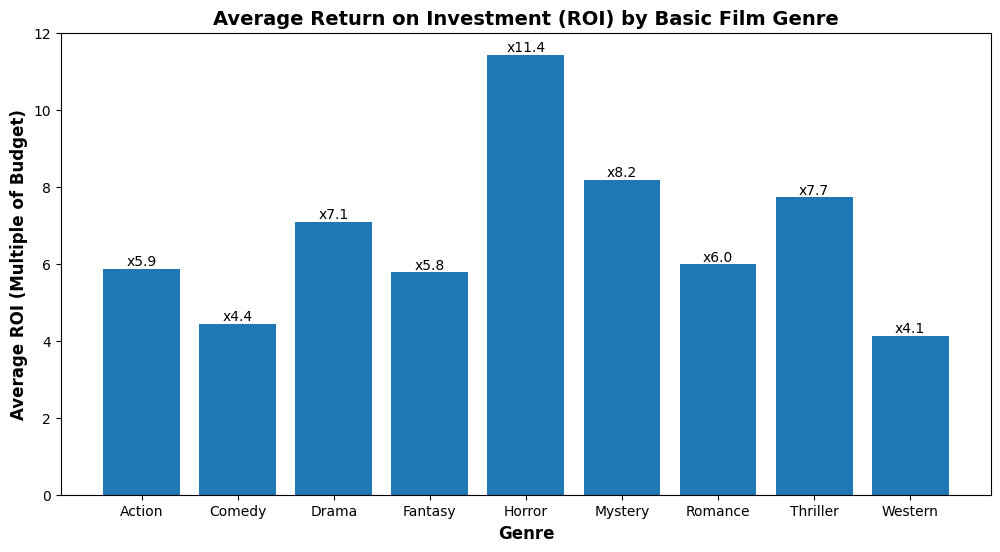

In [9]:
avg_rois = [df[df[genre]]['ROI'].mean() for genre in genres]

plt.figure(figsize=(12, 6))
bars = plt.bar(genres, avg_rois)

plt.title('Average Return on Investment (ROI) by Basic Film Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Average ROI (Multiple of Budget)', fontsize=12, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'x{yval:.1f}', ha='center', va='bottom')

plt.show()

### 3. Finer Details: Reception Independence
A common assumption among us viewers are we tend to read critics reviews to determine whether the film is good or not, before determining to go to actually watch the film. However, in this box plot, it tells a different story.

To demonstrate how horror genre has the highest ROI, we first look at how critics do not play a factor in determining the success rate for this genre. We divided the ratings to 4 equal sub-ratings. Across all ranges, the median ROI and overall spread remain relatively similar, with no clear upward trend as scores increase.

This indicates that higher ratings do not lead to higher profitability within the horror genre. Almost all of them remain above the break-even line `(y = 0)`, highlighting how horror is likely to perform well, regardless of review scores.

/var/folders/n_/z3k6p59n04s5zn2_bw06m2_h0000gn/T/ipykernel_22916/598902337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  horror_df['score_group'] = pd.qcut(horror_df['score'], 4)


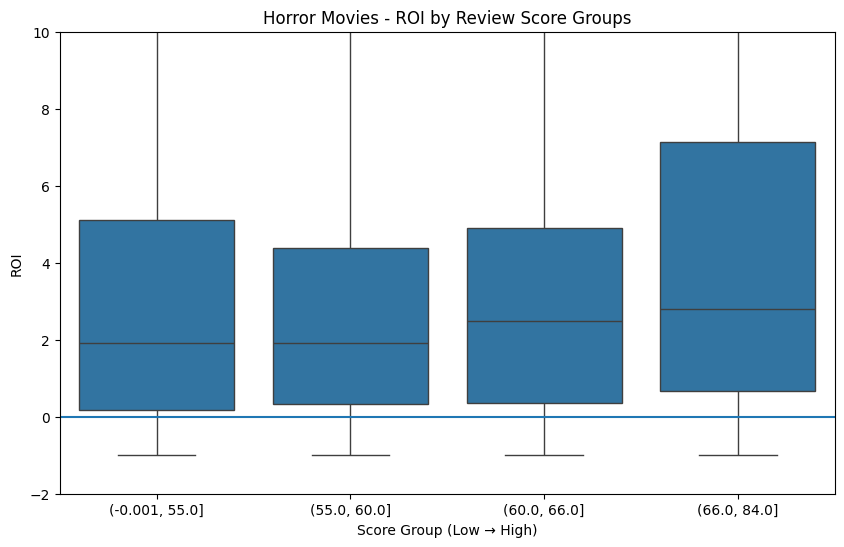

In [10]:
horror_df = df[df['Horror']]
horror_df['score_group'] = pd.qcut(horror_df['score'], 4)

plt.figure(figsize=(10, 6))
sns.boxplot(x='score_group', y='ROI', data=horror_df)

plt.axhline(0)
plt.title('Horror Movies - ROI by Review Score Groups')
plt.xlabel('Score Group (Low → High)')
plt.ylabel('ROI')
plt.ylim(-2, 10)

plt.show()

### 4. Low-Risk Entry
If horror yields the highest ROI, why doesn't it dominate total box office gross? The answer lies in its low barrier to entry.

Horror requires a fraction of the capital needed for Action, Fantasy, or Sci-Fi blockbusters — making it the industry's safest bet. Studios greenlight horror frequently precisely because the downside is minimal. The genre's exceptional ROI isn't just about returns; it's about how little you risk to get there.

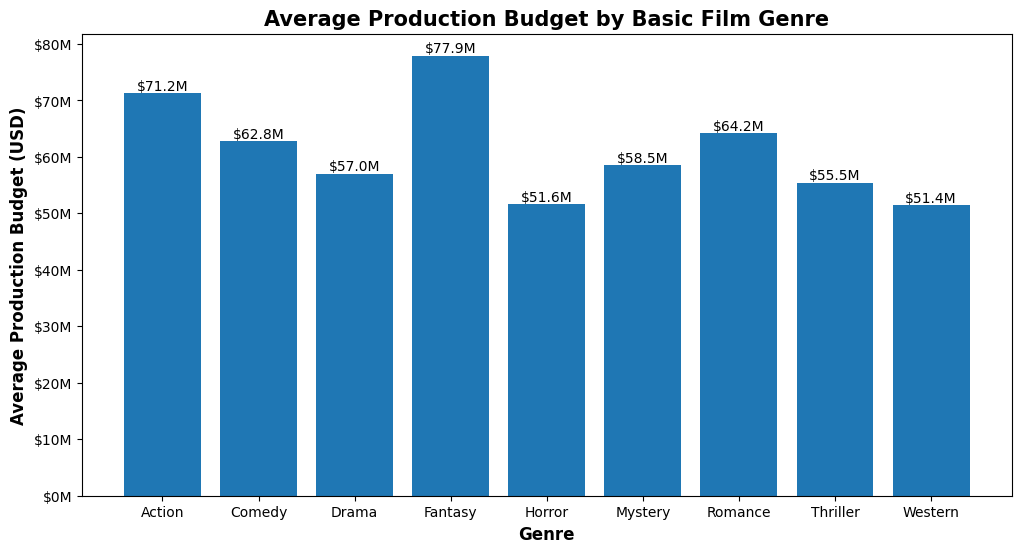

In [11]:
avg_budgets = [df[df[genre]]['budget_x'].mean() for genre in genres]

plt.figure(figsize=(12, 6))
bars = plt.bar(genres, avg_budgets)

plt.title('Average Production Budget by Basic Film Genre', fontsize=15, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Average Production Budget (USD)', fontsize=12, fontweight='bold')

from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'${x*1e-6:.0f}M'
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval*1e-6:.1f}M', ha='center', va='bottom')

plt.show()

*Citations:*
[1] PremiumBeat. "A Guide to Basic Film Genres." https://www.premiumbeat.com/blog/guide-to-basic-film-genres/

### Report
https://docs.google.com/document/d/1V7lCs1aDrzi4T5EeWfNMdvVFovdqq3C1TbdWqv-OaCQ/edit?tab=t.0